# Logistic regression analysis

Running this analysis requires access to the full UKB dataset, which is currently unavailable for this project (available in due course to approved researchers) 

In [31]:
import itertools
import itertools
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
import scipy.integrate as it
from scipy.stats import kde
import pandas as pd
from scipy.special import gamma
from IPython.display import clear_output
import string
import scipy.optimize as opt
import scipy.stats as stats
import matplotlib
matplotlib.rc_file_defaults()
matplotlib.rcParams['font.family'] = 'Lato'
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.gridspec as gridspec

import statsmodels.api as sm
import statsmodels.formula.api as smf

print('statsmodels', sm.__version__)

statsmodels 0.14.0


In [29]:
# phenotype file
biobank_pheno_cancer_smoking_BMI = pd.read_csv('data/biobank_pheno_cancer_smoking_BMI_select_columns_updated_2025_reclassified.tsv', sep='\t')

# ancestry file
ukb_ancestry = pd.read_csv('data/ukb_iadmix_ancestry_props.csv').rename(columns={'ukbid':'ID_v0'})

# TP53 variants
ukb_tp53_all = pd.read_csv('data/ukb_tp53_all_variants_unredacted.tsv', sep='\t')

### Set up regression data

In [3]:
data_reg = biobank_pheno_cancer_smoking_BMI[['ID_v0', 'Sex_v0', 'Ever.smoked_v0', 'Smoking_status', 'Smoking_level', 'pack_years', 'ten_pack_years', 'Body.mass.index..BMI._v0', 'Age.when.attended.assessment.centre_v0', 'cancer_status']].copy()
data_reg['cancer_01'] = 0
data_reg.loc[data_reg.cancer_status == 'retrospective', 'cancer_01'] = 1
data_reg = pd.merge(data_reg, ukb_ancestry[['ID_v0', 'iadmix_main_ancestry_v2']], how='left', on='ID_v0')

# scale bmi data
data_reg['BMI_scaled'] = (data_reg['Body.mass.index..BMI._v0'] - data_reg['Body.mass.index..BMI._v0'].mean()) / data_reg['Body.mass.index..BMI._v0'].std()

# convert smoking data to True/False
data_reg['Ever.smoked_v0'] = data_reg['Ever.smoked_v0'].map({'Yes':True, 'No':False})

In [4]:
data_reg['age_scaled'] = data_reg['Age.when.attended.assessment.centre_v0']/data_reg['Age.when.attended.assessment.centre_v0'].max()
data_reg['age_unscaled'] = data_reg['Age.when.attended.assessment.centre_v0'] # necessary as the statsmodels formula doesn't like '.' characters in variable names
data_reg['age_decade'] = data_reg['age_unscaled']/10

In [5]:
data_reg = pd.get_dummies(data_reg, columns=['iadmix_main_ancestry_v2'])
data_reg['Sex_male'] = data_reg['Sex_v0'] == 'Male'

In [6]:
# true or false variable for whether the person has had retrospective cancer (regardless of prospective cancer status)
# same as the cancer_01 variable but easier to remember
data_reg['cancer_retrospective'] = data_reg['cancer_status'] == 'retrospective'

In [7]:
# total number of individuals with cancer diagnoses before UKB assessment
data_reg['cancer_retrospective'].sum()

32902

### Test classes

In [8]:
# pathogenic variants
ukb_tp53_plp = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['Pathogenic', 'Likely_Pathogenic'])].reset_index(drop=True)
ukb_tp53_plp['pathogenic_variant'] = 1

# merge pathogenic carrier info into data_cox
data_reg = pd.merge(data_reg, ukb_tp53_plp[['ID_v0', 'pathogenic_variant']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_reg['pathogenic_variant'].replace(np.nan, 0., inplace=True)
data_reg['pathogenic_variant'] = data_reg['pathogenic_variant'].astype(int)
print(sum(data_reg['pathogenic_variant']))

312


In [9]:
# pathogenic variants (continuous VAF model)
data_reg = pd.merge(data_reg, ukb_tp53_plp[['ID_v0', 'VAF']].rename(columns={'VAF':'pathogenic_VAF'}), how='left', on='ID_v0').drop_duplicates('ID_v0')
data_reg['pathogenic_VAF'].replace(np.nan, 0, inplace=True)

In [20]:
# pathogenic varinats: classification
ukb_tp53_plp_likely = ukb_tp53_plp[ukb_tp53_plp.germ_likelihood == 'likely'].reset_index(drop=True)
ukb_tp53_plp_likely['plp_likely_germline'] = 1
data_reg = pd.merge(data_reg, ukb_tp53_plp_likely[['ID_v0', 'plp_likely_germline']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_reg['plp_likely_germline'].replace(np.nan, 0., inplace=True)
data_reg['plp_likely_germline'] = data_reg['plp_likely_germline'].astype(int)
print(sum(data_reg['plp_likely_germline']))

# unlikely germline
ukb_tp53_plp_unlikely = ukb_tp53_plp[ukb_tp53_plp.germ_likelihood == 'unlikely'].reset_index(drop=True)
ukb_tp53_plp_unlikely['plp_unlikely_germline'] = 1
data_reg = pd.merge(data_reg, ukb_tp53_plp_unlikely[['ID_v0', 'plp_unlikely_germline']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_reg['plp_unlikely_germline'].replace(np.nan, 0., inplace=True)
data_reg['plp_unlikely_germline'] = data_reg['plp_unlikely_germline'].astype(int)
print(sum(data_reg['plp_unlikely_germline']))

# inconclusive
ukb_tp53_plp_inconclusive = ukb_tp53_plp[ukb_tp53_plp.germ_likelihood == 'inconclusive'].reset_index(drop=True)
ukb_tp53_plp_inconclusive['plp_inconclusive'] = 1
data_reg = pd.merge(data_reg, ukb_tp53_plp_inconclusive[['ID_v0', 'plp_inconclusive']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_reg['plp_inconclusive'].replace(np.nan, 0., inplace=True)
data_reg['plp_inconclusive'] = data_reg['plp_inconclusive'].astype(int)
print(sum(data_reg['plp_inconclusive']))

53
217
43


In [10]:
# region benign variants
ukb_tp53_blb = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['Benign', 'Likely_Benign'])].reset_index(drop=True)
ukb_tp53_blb['benign_variant'] = 1

# merge benign carrier info into data_cox
data_reg = pd.merge(data_reg, ukb_tp53_blb[['ID_v0', 'benign_variant']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_reg['benign_variant'].replace(np.nan, 0., inplace=True)
data_reg['benign_variant'] = data_reg['benign_variant'].astype(int)
print(sum(data_reg['benign_variant']))
# endregion

1094


In [11]:
# synonymous variants
ukb_tp53_syn = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model == 'Synonymous'].reset_index(drop=True)
ukb_tp53_syn['synonymous_variant'] = 1

# merge benign carrier info into data_cox
data_reg = pd.merge(data_reg, ukb_tp53_syn[['ID_v0', 'synonymous_variant']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_reg['synonymous_variant'].replace(np.nan, 0., inplace=True)
data_reg['synonymous_variant'] = data_reg['synonymous_variant'].astype(int)
print(sum(data_reg['synonymous_variant']))

1299


### Models

Key: 
- ES: ever smoker/never smoker
- CFN: current/former/never smoker
- PY: pack years
- RC: include retrospective cancer
- NRC: exclude retrospective cancer

In [12]:
all_models = {}
columns_dict = {}
tick_names_dict = {}

In [13]:
ancestry_correction = ' + iadmix_main_ancestry_v2_AFR + iadmix_main_ancestry_v2_EAS + iadmix_main_ancestry_v2_Mixed + iadmix_main_ancestry_v2_SAS'

In [14]:
# feed it a fitted model object and it will extract parameters for you
def get_model_results(model, columns):
    df = pd.DataFrame({'log_OR':model.params[columns],
                       'CI_lower':model.conf_int().loc[columns][0],
                       'CI_upper':model.conf_int().loc[columns][1]})
    df['lower_error'] = df['log_OR'] - df['CI_lower']
    df['upper_error'] = df['CI_upper'] - df['log_OR']
    df['p_value'] = model.pvalues
    return df

Any pathogenic variant ~ factors, (ever smoked)

In [15]:
model_name = 'ES_RC_anypath'
formula = 'pathogenic_variant ~ age_decade + Ever_smoked_v0 + BMI_scaled + Sex_male + cancer_retrospective'+ancestry_correction

columns_dict[model_name] = ['age_decade', 'Ever_smoked_v0[T.True]', 'Sex_male[T.True]', 'BMI_scaled']
tick_names_dict[model_name] = ['Age (decade)', 'Ever smoked', 'Sex (M)', 'BMI']

all_models[model_name] = smf.glm(formula=formula, data=data_reg.rename(columns={"Ever.smoked_v0":'Ever_smoked_v0'}), family=sm.families.Binomial()).fit()

Any pathogenic variant ~ factors, (current, former, never)

In [16]:
model_name = 'CFN_RC_anypath'
formula = "pathogenic_variant ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male + cancer_retrospective"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled', 'cancer_retrospective[T.True]']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI', 'Previous cancer']

all_models[model_name] = smf.glm(formula=formula, data=data_reg.rename(columns={"Ever.smoked_v0":'Ever_smoked_v0'}), family=sm.families.Binomial()).fit()

Any pathogenic variant ~ factors, CFN, excluding history of cancer

In [17]:
data_reg_for_processing = data_reg[data_reg.cancer_retrospective == False]

model_name = 'CFN_NRC_anypath'
formula = "pathogenic_variant ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI']

all_models[model_name] = smf.glm(formula=formula, data=data_reg_for_processing.rename(columns={"Ever.smoked_v0":'Ever_smoked_v0'}), family=sm.families.Binomial()).fit()

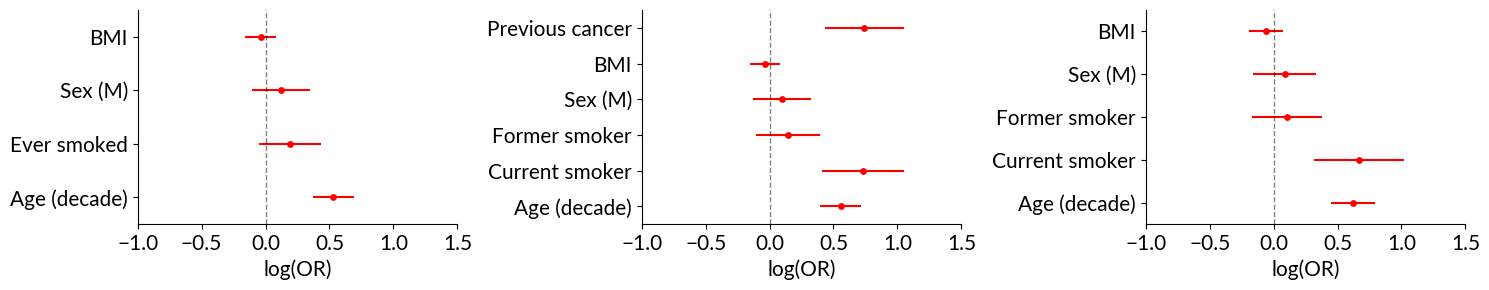

In [18]:
fig, ax = plt.subplots(1, 3, figsize=[15, 3])
for i, model_name in enumerate(['ES_RC_anypath', 'CFN_RC_anypath', 'CFN_NRC_anypath']):

    df = get_model_results(all_models[model_name], columns_dict[model_name])
    ax[i].scatter(df.log_OR, np.arange(len(df)), marker='o', c='red', s=15)
    ax[i].errorbar(df.log_OR, np.arange(len(df)), xerr=[df['lower_error'], df['upper_error']], ls='none', zorder=-1, color='red', capsize=0)

    ax[i].set_yticks(np.arange(len(df)))
    ax[i].set_yticklabels(tick_names_dict[model_name])
    ax[i].set_xlim(-1, 1.5)
    ax[i].vlines(0, -0.5, len(df)-0.5, color='k', ls='dashed', lw=1, alpha=0.5)
    ax[i].set_ylim(-0.5, len(df)-0.5)
    ax[i].set_xlabel('log(OR)')
plt.tight_layout()

Broken down by classfication

Each class ~ factors (CFN)

In [21]:
model_name = 'CFN_RC_path_germ'
formula = "plp_likely_germline ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male + cancer_retrospective"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled', 'cancer_retrospective[T.True]']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI', 'Previous cancer']

all_models[model_name] = smf.glm(formula=formula, data=data_reg, family=sm.families.Binomial()).fit()

model_name = 'CFN_RC_path_ungerm'
formula = "plp_unlikely_germline ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male + cancer_retrospective"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled', 'cancer_retrospective[T.True]']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI', 'Previous cancer']

all_models[model_name] = smf.glm(formula=formula, data=data_reg, family=sm.families.Binomial()).fit()

model_name = 'CFN_RC_path_inc'
formula = "plp_inconclusive ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male + cancer_retrospective"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled', 'cancer_retrospective[T.True]']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI', 'Previous cancer']

all_models[model_name] = smf.glm(formula=formula, data=data_reg, family=sm.families.Binomial()).fit()

Each class ~ factors (CFN) excluding previous cancer

In [22]:
data_reg_for_processing = data_reg[data_reg.cancer_retrospective == False]

model_name = 'CFN_NRC_path_germ'
formula = "plp_likely_germline ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI']

all_models[model_name] = smf.glm(formula=formula, data=data_reg_for_processing, family=sm.families.Binomial()).fit()

model_name = 'CFN_NRC_path_ungerm'
formula = "plp_unlikely_germline ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI']

all_models[model_name] = smf.glm(formula=formula, data=data_reg_for_processing, family=sm.families.Binomial()).fit()

model_name = 'CFN_NRC_path_inc'
formula = "plp_inconclusive ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI']

all_models[model_name] = smf.glm(formula=formula, data=data_reg_for_processing, family=sm.families.Binomial()).fit()

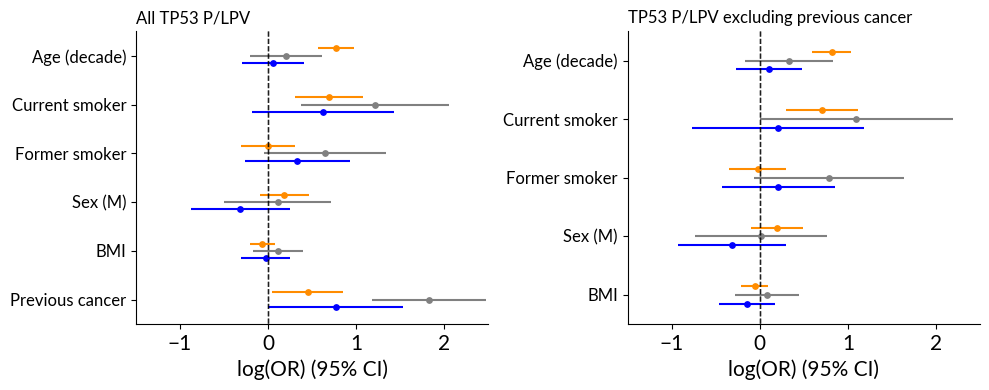

In [23]:
fig, ax = plt.subplots(1, 2, figsize=[10, 4])

i = 0
pos_list = [-0.15, 0, 0.15]
colour_list = ['darkorange', 'grey', 'blue']
for j, model_name in enumerate(['CFN_RC_path_ungerm', 'CFN_RC_path_inc', 'CFN_RC_path_germ']):
    df = get_model_results(all_models[model_name], columns_dict[model_name])
    df = get_model_results(all_models[model_name], columns_dict[model_name])
    ax[i].scatter(df.log_OR, np.arange(len(df))+pos_list[j], marker='o', c=colour_list[j], s=15)
    ax[i].errorbar(df.log_OR, np.arange(len(df))+pos_list[j], xerr=[df['lower_error'], df['upper_error']], ls='none', zorder=-1, color=colour_list[j], capsize=0)
    ax[i].set_yticks(np.arange(len(df)))
    ax[i].set_yticklabels(tick_names_dict[model_name], fontsize=12)
    ax[i].vlines(0, -0.5, len(df)-0.5, color='k', ls='dashed', lw=1, alpha=0.5)
    ax[i].set_ylim(-0.5, len(df)-0.5)
    ax[i].set_title('All TP53 P/LPV', loc='left')
    ax[i].invert_yaxis()

i = 1
for j, model_name in enumerate(['CFN_NRC_path_ungerm', 'CFN_NRC_path_inc', 'CFN_NRC_path_germ']):
    df = get_model_results(all_models[model_name], columns_dict[model_name])
    df = get_model_results(all_models[model_name], columns_dict[model_name])
    ax[i].scatter(df.log_OR, np.arange(len(df))+pos_list[j], marker='o', c=colour_list[j], s=15)
    ax[i].errorbar(df.log_OR, np.arange(len(df))+pos_list[j], xerr=[df['lower_error'], df['upper_error']], ls='none', zorder=-1, color=colour_list[j], capsize=0)
    ax[i].set_yticks(np.arange(len(df)))
    ax[i].set_yticklabels(tick_names_dict[model_name], fontsize=12)
    ax[i].vlines(0, -0.5, len(df)-0.5, color='k', ls='dashed', lw=1, alpha=0.5)
    ax[i].set_ylim(-0.5, len(df)-0.5)
    ax[i].set_title('TP53 P/LPV excluding previous cancer', loc='left')
    ax[i].invert_yaxis()


for i in range(2):
    ax[i].set_xlim(-1.5, 2.5)
    ax[i].set_xlabel('log(OR) (95% CI)')
    
plt.tight_layout()
#plt.savefig('../Thesis files/figures_tp53/regression_casecontrol.pdf')

In [29]:
columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled', 'cancer_retrospective[T.True]']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI', 'Previous cancer']


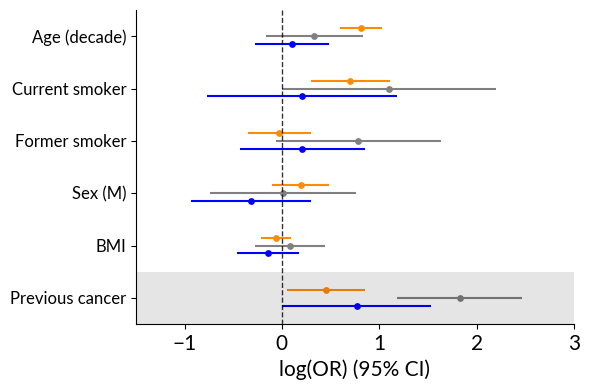

In [24]:
fig, ax = plt.subplots(1, 1, figsize=[6, 4])

for j, model_name in enumerate(['CFN_NRC_path_ungerm', 'CFN_NRC_path_inc', 'CFN_NRC_path_germ']):
    df = get_model_results(all_models[model_name], columns_dict[model_name])
    ax.scatter(df.log_OR, np.arange(len(df))+pos_list[j], marker='o', c=colour_list[j], s=15)
    ax.errorbar(df.log_OR, np.arange(len(df))+pos_list[j], xerr=[df['lower_error'], df['upper_error']], ls='none', zorder=-1, color=colour_list[j], capsize=0)
    #ax.set_yticks(np.arange(len(df)))
    #ax.set_yticklabels(tick_names_dict[model_name], fontsize=12)
    #ax.vlines(0, -0.5, len(df)-0.5, color='k', ls='dashed', lw=1, alpha=0.5)
    #ax.set_ylim(-0.5, len(df)-0.5)
    #ax.set_title('TP53 P/LPV excluding previous cancer', loc='left')
    ax.invert_yaxis()

# include cancer history in main figure
for j, model_name in enumerate(['CFN_RC_path_ungerm', 'CFN_RC_path_inc', 'CFN_RC_path_germ']):
    df = get_model_results(all_models[model_name], columns_dict[model_name])
    row = df.loc['cancer_retrospective[T.True]']
    ax.scatter(row.log_OR, len(df)-1 + pos_list[j], marker='o', c=colour_list[j], s=15)
    ax.errorbar(row.log_OR, len(df)-1+pos_list[j], xerr=[[row['lower_error']], [row['upper_error']]], ls='none', zorder=-1, color=colour_list[j], capsize=0)

ax.set_yticks(np.arange(len(df)))
ax.set_yticklabels(tick_names_dict[model_name], fontsize=12)
ax.vlines(0, -0.5, len(df)+0.5, color='k', ls='dashed', lw=1, alpha=0.8)
ax.set_ylim(-0.5, len(df)-0.5)
ax.set_xlim(-1.5, 3)
ax.set_xlabel('log(OR) (95% CI)')
ax.fill_between([-1.5, 3], [len(df)-1.5, len(df)-1.5], [len(df)-0.5, len(df)-0.5], alpha=0.1, color='k', edgecolor='none')
ax.invert_yaxis()
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/regression_casecontrol_integrated_no_manual_assignment.pdf')

### Tables of values and supplementary figure 6

Without history of cancer

In [35]:
results_df = pd.DataFrame([])
replace_dict = {'age_decade':'age (per decade)',
                "C(Smoking_status, Treatment(reference='Never'))[T.Current]":'Current smoker',
                "C(Smoking_status, Treatment(reference='Never'))[T.Ex]":'Former smoker',
                'Sex_male[T.True]':'Sex (male)',
                'BMI_scaled':'BMI (Z-scaled)'}
model_name_dict = {'CFN_NRC_path_ungerm':'likely somatic', 'CFN_NRC_path_inc':'inconclusive', 'CFN_NRC_path_germ':'likely germline'}
column_order = ['variant_class', 'covariate', 'log_OR', 'CI_lower', 'CI_upper', 'p_value']
for j, model_name in enumerate(['CFN_NRC_path_ungerm', 'CFN_NRC_path_inc', 'CFN_NRC_path_germ']):
    df = get_model_results(all_models[model_name], columns_dict[model_name])
    df['variant_class'] = model_name_dict[model_name]
    if len(results_df) == 0:
        
        results_df = df.reset_index().rename(columns={'index':'covariate'})
    else:
        results_df = pd.concat([results_df, df.reset_index().rename(columns={'index':'covariate'})], axis=0)
    
results_df['covariate'] = results_df['covariate'].replace(replace_dict)

results_df[column_order].to_csv('TP53_manuscript/tables/linear_regression_excluding_history_of_cancer_reclassified.csv', index=False)

In [36]:
results_df = pd.DataFrame([])
replace_dict = {'age_decade':'age (per decade)',
                "C(Smoking_status, Treatment(reference='Never'))[T.Current]":'Current smoker',
                "C(Smoking_status, Treatment(reference='Never'))[T.Ex]":'Former smoker',
                'Sex_male[T.True]':'Sex (male)',
                'BMI_scaled':'BMI (Z-scaled)',
                'cancer_retrospective[T.True]':'previous cancer'}
model_name_dict = {'CFN_RC_path_ungerm':'likely somatic', 'CFN_RC_path_inc':'inconclusive', 'CFN_RC_path_germ':'likely germline'}
column_order = ['variant_class', 'covariate', 'log_OR', 'CI_lower', 'CI_upper', 'p_value']
for j, model_name in enumerate(['CFN_RC_path_ungerm', 'CFN_RC_path_inc', 'CFN_RC_path_germ']):
    df = get_model_results(all_models[model_name], columns_dict[model_name])
    df['variant_class'] = model_name_dict[model_name]
    if len(results_df) == 0:

        results_df = df.reset_index().rename(columns={'index':'covariate'})
    else:
        results_df = pd.concat([results_df, df.reset_index().rename(columns={'index':'covariate'})], axis=0)

results_df['covariate'] = results_df['covariate'].replace(replace_dict)

results_df[column_order].to_csv('TP53_manuscript/tables/linear_regression_including_history_of_cancer_reclassified.csv', index=False)

### Benign and synonymous variants

In [37]:
model_name = 'CFN_RC_benign'
formula = "benign_variant ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male + cancer_retrospective"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled', 'cancer_retrospective[T.True]']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI', 'Previous cancer']

all_models[model_name] = smf.glm(formula=formula, data=data_reg.rename(columns={"Ever.smoked_v0":'Ever_smoked_v0'}), family=sm.families.Binomial()).fit()

In [38]:
model_name = 'CFN_RC_synonymous'
formula = "synonymous_variant ~ age_decade + C(Smoking_status, Treatment(reference='Never')) + BMI_scaled + Sex_male + cancer_retrospective"+ancestry_correction

columns_dict[model_name] = ['age_decade', "C(Smoking_status, Treatment(reference='Never'))[T.Current]", "C(Smoking_status, Treatment(reference='Never'))[T.Ex]", 'Sex_male[T.True]', 'BMI_scaled', 'cancer_retrospective[T.True]']
tick_names_dict[model_name]  = ['Age (decade)', 'Current smoker', 'Former smoker', 'Sex (M)', 'BMI', 'Previous cancer']

all_models[model_name] = smf.glm(formula=formula, data=data_reg.rename(columns={"Ever.smoked_v0":'Ever_smoked_v0'}), family=sm.families.Binomial()).fit()

In [39]:
model_name = 'CFN_RC_benign'
df = get_model_results(all_models[model_name], columns_dict[model_name])
df['OR'] = np.exp(df['log_OR'])
df['CI_lower_exp'] = np.exp(df['CI_lower'])
df['CI_upper_exp'] = np.exp(df['CI_upper'])
df[['log_OR', 'CI_lower', 'CI_upper', 'OR', 'CI_lower_exp', 'CI_upper_exp','p_value']]

,log_OR,CI_lower,CI_upper,OR,CI_lower_exp,CI_upper_exp,p_value
age_decade,-0.022955,-0.098373,0.052464,0.977307,0.906311,1.053864,0.550811
"C(Smoking_status, Treatment(reference='Never'))[T.Current]",-0.064919,-0.271122,0.141284,0.937143,0.762523,1.151752,0.537197
"C(Smoking_status, Treatment(reference='Never'))[T.Ex]",0.010714,-0.122782,0.144209,1.010771,0.884457,1.155126,0.875010
Sex_male[T.True],0.078942,-0.042203,0.200088,1.082142,0.958675,1.221510,0.201541
BMI_scaled,-0.026459,-0.087789,0.034870,0.973888,0.915954,1.035485,0.397783
cancer_retrospective[T.True],0.071731,-0.159978,0.303439,1.074366,0.852163,1.354509,0.544016


In [40]:
model_name = 'CFN_RC_synonymous'
df = get_model_results(all_models[model_name], columns_dict[model_name])
df['OR'] = np.exp(df['log_OR'])
df['CI_lower_exp'] = np.exp(df['CI_lower'])
df['CI_upper_exp'] = np.exp(df['CI_upper'])
df[['log_OR', 'CI_lower', 'CI_upper', 'OR', 'CI_lower_exp', 'CI_upper_exp','p_value']]

,log_OR,CI_lower,CI_upper,OR,CI_lower_exp,CI_upper_exp,p_value
age_decade,-0.054627,-0.123332,0.014077,0.946838,0.883971,1.014177,0.119144
"C(Smoking_status, Treatment(reference='Never'))[T.Current]",0.038145,-0.144678,0.220969,1.038882,0.865301,1.247284,0.682584
"C(Smoking_status, Treatment(reference='Never'))[T.Ex]",0.039109,-0.083699,0.161918,1.039884,0.919708,1.175764,0.532517
Sex_male[T.True],-0.021341,-0.132603,0.089920,0.978885,0.875813,1.094087,0.706955
BMI_scaled,-0.011897,-0.067526,0.043731,0.988173,0.934704,1.044701,0.675085
cancer_retrospective[T.True],0.205117,0.002818,0.407415,1.227669,1.002822,1.502928,0.046892


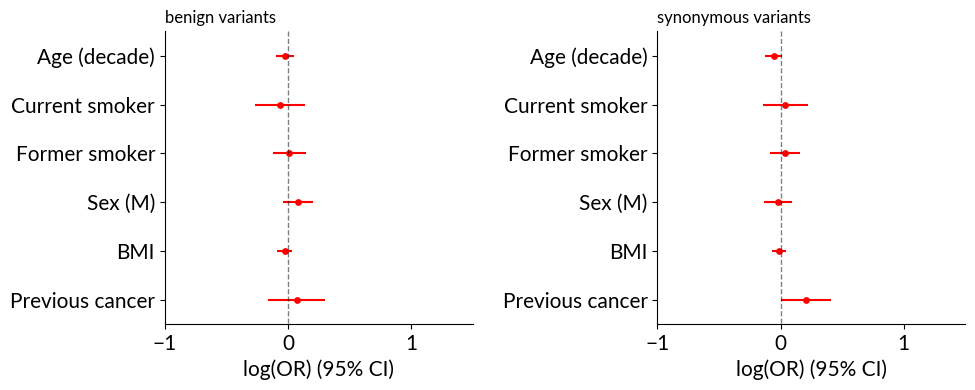

In [41]:
fig, ax = plt.subplots(1, 2, figsize=[10, 4])
for i, model_name in enumerate(['CFN_RC_benign', 'CFN_RC_synonymous']):

    df = get_model_results(all_models[model_name], columns_dict[model_name])
    ax[i].scatter(df.log_OR, np.arange(len(df)), marker='o', c='red', s=15)
    ax[i].errorbar(df.log_OR, np.arange(len(df)), xerr=[df['lower_error'], df['upper_error']], ls='none', zorder=-1, color='red', capsize=0)

    ax[i].set_yticks(np.arange(len(df)))
    ax[i].set_yticklabels(tick_names_dict[model_name])
    ax[i].set_xlim(-1, 1.5)
    ax[i].vlines(0, -0.5, len(df)-0.5, color='k', ls='dashed', lw=1, alpha=0.5)
    ax[i].set_ylim(-0.5, len(df)-0.5)
    ax[i].set_xlabel('log(OR) (95% CI)')
    ax[i].set_title(['benign variants', 'synonymous variants'][i], loc='left')
    ax[i].invert_yaxis()
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/benign_and_synonymous_predictors.pdf')